# Gaussian process regression

## From a prior over functions to predictions

Gaussian process regression (GPR) is a probabilistic, non-parametric approach to regression: instead of fitting a single function with fixed parameters, we place a probability distribution directly over the space of *functions* that could explain the data, and then condition on the observed training points. It delivers not just a point prediction but a full predictive *distribution* — giving calibrated uncertainty estimates alongside every prediction.

A Gaussian process is fully specified by a mean function (often taken to be zero) and a covariance (*kernel*) function $k(\boldsymbol{x}, \boldsymbol{x}')$, which encodes how strongly the function values at two input points are expected to be correlated. A common choice is the radial basis function (RBF) kernel,

$$
k(\boldsymbol{x}, \boldsymbol{x}') = \sigma_f^2 \exp\!\left( -\frac{\lVert \boldsymbol{x} - \boldsymbol{x}' \rVert^2}{2\ell^2} \right)
$$

where the length scale $\ell$ controls how quickly correlations decay with distance, and $\sigma_f^2$ is the overall signal variance. Nearby inputs are expected to give similar outputs; the kernel turns this assumption into a precise statistical model.

Given training inputs $\boldsymbol{X}$ with observed (noisy) targets $\boldsymbol{y}$ (noise variance $\sigma_n^2$), the predictive distribution at a new point $\boldsymbol{x}_*$ is Gaussian with mean and variance

$$
\mu_* = \boldsymbol{k}_*^\top \left(\boldsymbol{K} + \sigma_n^2 \boldsymbol{I}\right)^{-1} \boldsymbol{y}, \qquad
\sigma_*^2 = k(\boldsymbol{x}_*, \boldsymbol{x}_*) - \boldsymbol{k}_*^\top \left(\boldsymbol{K} + \sigma_n^2 \boldsymbol{I}\right)^{-1} \boldsymbol{k}_*
$$

where $\boldsymbol{K}$ is the matrix of kernel values between all training points, and $\boldsymbol{k}_*$ is the vector of kernel values between the test point and the training points. The key feature of GPR compared to most other regression methods is the predictive variance $\sigma_*^2$: it is large where the model is uncertain (far from training data) and small near well-observed regions.

## Library imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use the **diabetes data set** bundled with `sklearn`: 442 patients, 10 physiological features (age, sex, BMI, blood pressure, and six blood serum measurements), and a continuous target measuring disease progression one year after baseline. This is a classical small-scale biomedical regression benchmark.

To get a 1D visualization that cleanly shows the GPR uncertainty bands of Eq. (2), we first show a single-feature model (BMI); we then also fit a full 10-feature model to demonstrate the multi-input use case.

In [2]:
diabetes = sklearn.datasets.load_diabetes()
X_all = diabetes.data
y_all = diabetes.target

print("Number of patients  :", X_all.shape[0])
print("Number of features  :", X_all.shape[1])
print("Feature names       :", diabetes.feature_names)
print("Target range        :", y_all.min(), "–", y_all.max())


Number of patients  : 442
Number of features  : 10
Feature names       : ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target range        : 25.0 – 346.0


### 1D case (BMI feature)

We use a 100-sample subset for the 1D visualization.

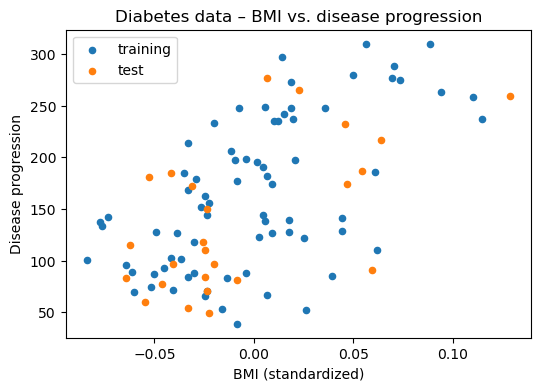

In [3]:
rng = np.random.default_rng(0)
idx_sub = rng.choice(len(y_all), size=100, replace=False)
X_sub = X_all[idx_sub, 2].reshape(-1, 1)  # column 2 = BMI
y_sub = y_all[idx_sub]

X_train_1d, X_test_1d, y_train_1d, y_test_1d = sklearn.model_selection.train_test_split(
    X_sub, y_sub, test_size=0.25, random_state=0,
)

plt.figure(figsize=(6, 4))
plt.scatter(X_train_1d, y_train_1d, label="training", color="tab:blue", s=20)
plt.scatter(X_test_1d,  y_test_1d,  label="test",     color="tab:orange", s=20)
plt.xlabel("BMI (standardized)"); plt.ylabel("Disease progression")
plt.legend(); plt.title("Diabetes data – BMI vs. disease progression")
plt.show()


## Model definition

We use the RBF kernel of Eq. (1), implemented in `sklearn.gaussian_process.kernels`, combined with a white-noise kernel representing $\sigma_n^2$ in Eq. (2). The kernel hyperparameters ($\ell$, $\sigma_f^2$, $\sigma_n^2$) are automatically optimized by maximizing the marginal likelihood when the model is fitted.

In [4]:
kernel = (
    sklearn.gaussian_process.kernels.ConstantKernel(1.0)
    * sklearn.gaussian_process.kernels.RBF(length_scale=1.0)
    + sklearn.gaussian_process.kernels.WhiteKernel(noise_level=1.0)
)

gpr_1d = sklearn.gaussian_process.GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=5,
    normalize_y=True,
)


## Model training (1D)

In [5]:
gpr_1d.fit(X_train_1d, y_train_1d)
print("Optimized kernel:", gpr_1d.kernel_)


Optimized kernel: 1.03**2 * RBF(length_scale=0.11) + WhiteKernel(noise_level=0.679)


## Prediction and uncertainty visualization

We predict the mean $\mu_*$ and standard deviation $\sigma_*$ from Eq. (2) on a fine grid and plot the 95% confidence band ($\pm 1.96\,\sigma_*$).

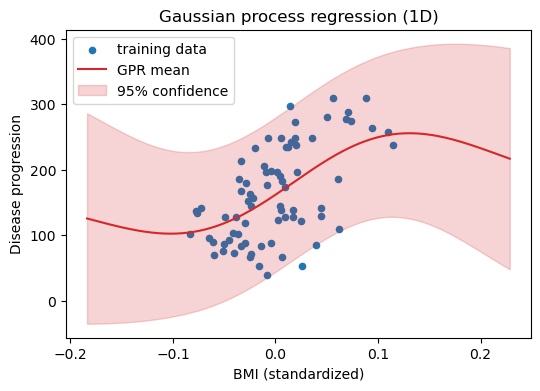

In [6]:
X_grid = np.linspace(X_sub.min() - 0.1, X_sub.max() + 0.1, 300).reshape(-1, 1)
y_mean, y_std = gpr_1d.predict(X_grid, return_std=True)

plt.figure(figsize=(6, 4))
plt.scatter(X_train_1d, y_train_1d, color="tab:blue", s=20, label="training data")
plt.plot(X_grid, y_mean, color="tab:red", label="GPR mean")
plt.fill_between(
    X_grid.ravel(),
    y_mean - 1.96 * y_std,
    y_mean + 1.96 * y_std,
    color="tab:red", alpha=0.2, label="95% confidence",
)
plt.xlabel("BMI (standardized)"); plt.ylabel("Disease progression")
plt.legend(); plt.title("Gaussian process regression (1D)")
plt.show()


Notice that the confidence band is narrow in regions with many training points and widens where data are sparse — exactly what one would want from a model that is honest about its own uncertainty.

## Full model (all 10 features)

For the multi-input case we use all 442 patients and all 10 features, and evaluate with R².

In [7]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X_all, y_all, test_size=0.20, random_state=0,
)

kernel_full = (
    sklearn.gaussian_process.kernels.ConstantKernel(1.0)
    * sklearn.gaussian_process.kernels.RBF(length_scale=np.ones(X_all.shape[1]))
    + sklearn.gaussian_process.kernels.WhiteKernel(noise_level=1.0)
)

gpr_full = sklearn.gaussian_process.GaussianProcessRegressor(
    kernel=kernel_full,
    n_restarts_optimizer=3,
    normalize_y=True,
)

gpr_full.fit(X_train, y_train)
r2 = gpr_full.score(X_test, y_test)
print(f"Test R²: {r2:.3f}")


Test R²: 0.330


### Predicted vs. actual plot

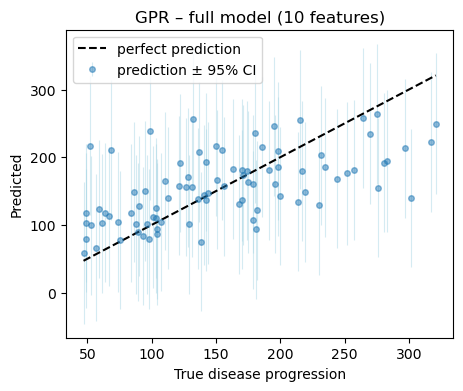

In [8]:
y_pred_full, y_std_full = gpr_full.predict(X_test, return_std=True)

plt.figure(figsize=(5, 4))
plt.errorbar(
    y_test, y_pred_full,
    yerr=1.96 * y_std_full,
    fmt="o", ms=4, alpha=0.5, elinewidth=0.8,
    color="tab:blue", ecolor="lightblue",
    label="prediction ± 95% CI",
)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "k--", label="perfect prediction")
plt.xlabel("True disease progression"); plt.ylabel("Predicted")
plt.legend(); plt.title("GPR – full model (10 features)")
plt.show()


## Cross-validation and model selection

The kernel type and its initial hyperparameters can substantially affect the result. `sklearn.model_selection.cross_val_score` with a `GaussianProcessRegressor` estimator can be used to compare kernel choices; `GridSearchCV` or `RandomizedSearchCV` can tune additional settings such as `n_restarts_optimizer` and the initial length scale values.

## Take-away

GPR is particularly attractive with limited data: it works well with only a handful of observations, requires few hyperparameters (which are optimized from the data automatically), and provides calibrated predictive uncertainty out of the box — useful whenever a downstream decision depends not just on the predicted value but on how confident the model is. Its main practical limitation is computational cost: computing and inverting the kernel matrix $\boldsymbol{K}$ in Eq. (2) scales as $\mathcal{O}(N^3)$, which makes plain GPR impractical beyond a few thousand training points. For larger data sets, approximate methods (sparse GP, inducing points) are needed.